# **Regresión Polinomial**

Cuando trabajamos con datos del mundo real, a menudo descubrimos que las relaciones entre las variables no son lineales. ¿Qué ocurre cuando una simple línea recta no es suficiente para describir el comportamiento de los datos?  
Sorprendentemente, **podemos seguir utilizando modelos lineales** para capturar relaciones no lineales mediante una técnica muy poderosa: la **regresión polinomial**.

La idea central es ampliar el espacio de características añadiendo **potencias** (cuadrados, cubos, etc.) de cada una de las variables originales. Luego, entrenamos un modelo lineal sobre este conjunto extendido. Aunque el modelo es lineal en sus parámetros, puede representar relaciones altamente no lineales entre las variables.




## 🧠 **Sobreajuste vs. Subajuste**

El rendimiento de un modelo depende de dos fenómenos fundamentales:

### 🔹 **Subajuste (underfitting)**
Ocurre cuando el modelo es **demasiado simple** para capturar la estructura de los datos.  
Características:
- Bajo desempeño tanto en entrenamiento como en prueba  
- El modelo no logra aprender patrones relevantes

### 🔹 **Sobreajuste (overfitting)**
Ocurre cuando el modelo es **demasiado complejo** y aprende no solo los patrones útiles, sino también el **ruido** en los datos.  
Características:
- Alto desempeño en entrenamiento  
- Mal desempeño en prueba  
- Generaliza mal a nuevos datos



## 🛠️ **Cómo abordar estos problemas**

- Para **subajuste**, podemos aumentar la complejidad del modelo, por ejemplo:
  - Añadiendo características polinómicas
  - Usando modelos más expresivos
  - Recolectando más datos o diseñando mejores características  

- Para **sobreajuste**, existen técnicas como:
  - **Regularización** (L1, L2)  
  - Recolección de más datos  
  - Reducción de la complejidad del modelo  
  - Validación cruzada para elegir hiperparámetros  

En este laboratorio nos enfocaremos en **uso de regresión polinomial para aumentar la complejidad del modelo**, incluso hasta llegar al punto de sobreajuste para evaluar si contamos con datos suficientes.



## 🎯 **¿Qué haremos en este cuaderno?**

En este notebook exploraremos:
- Cómo aplicar **transformaciones polinómicas** a datos univariados y multivariados
- Cómo ajustar un modelo lineal usando características polinómicas
- Cómo visualizar los efectos del grado del polinomio sobre el ajuste del modelo
- Cómo identificar visualmente sobreajuste y subajuste
- Cómo usar un conjunto de validación para seleccionar el mejor grado polinómico
- Cómo realizar una **búsqueda de cuadrícula (Grid Search)** de hiperparámetros



## ✅ **Objetivos de aprendizaje**

Al finalizar este laboratorio, usted será capaz de:

- Comprender claramente la diferencia entre **sobreajuste** y **subajuste**
- Aplicar **transformaciones polinómicas** a conjuntos de datos
- Entrenar modelos lineales polinomiales con distintos grados
- Visualizar y diagnosticar comportamientos de ajuste
- Evaluar modelos utilizando datos de validación
- Implementar una **búsqueda de cuadrícula (Grid Search)** para optimizar hiperparámetros


## Configuración 
Para este laboratorio, utilizaremos las siguientes bibliotecas:

-  [`pandas`](https://pandas.pydata.org/)  para gestionar los datos.
 - [`numpy`](https://numpy.org/) para operaciones matemáticas.
- [`seaborn`](https://seaborn.pydata.org/) para visualizar los datos.
 - [`matplotlib`](https://matplotlib.org/)  para visualizar los datos.
 - [`sklearn`](https://scikit-learn.org/stable/)  para funciones relacionadas con el aprendizaje automático y la canalización del aprendizaje automático.
 - [`scipy`](https://docs.scipy.org/doc/scipy/tutorial/stats.html/) para cálculos estadísticos.



***


In [4]:
# Surpress warnings:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn
import sys
# Agregar la ruta donde se encuentra tu archivo .py
sys.path.append(r"C:\Users\LENOVO\Downloads\Latex\CursosML\IBM")

# Ahora puedes importar tu módulo
import Funciones_ML as ML

In [5]:
import pandas as pd
import numpy as np 

import seaborn as sns 
import matplotlib.pylab as plt
%matplotlib inline

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import scale
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV

La siguiente función calculará el  $R^{2}$  
en cada característica dado el modelo de entrada.

In [7]:
def get_R2_features(model, test=True): 
    # X: global  
    # Se asume que X es un DataFrame global con todas las variables predictoras.

    features = list(X)           # Obtiene la lista de columnas (features) de X
    features.remove("three")     # Elimina la feature "three" de la evaluación
    
    R_2_train = []               # Lista para guardar los R² del entrenamiento
    R_2_test = []                # Lista para guardar los R² del test

    # Itera por cada feature restante
    for feature in features:
        # Entrena el modelo usando SOLO esa feature
        model.fit(X_train[[feature]], y_train)
        
        # Guarda el R² para test y train
        R_2_test.append(model.score(X_test[[feature]], y_test))
        R_2_train.append(model.score(X_train[[feature]], y_train))
        
    
    # Grafica las barras comparativas
    plt.bar(features, R_2_train, label="Train")
    plt.bar(features, R_2_test, label="Test")
    plt.xticks(rotation=90)
    plt.ylabel("$R^2$")
    plt.legend()
    plt.show()

    # Imprime resúmenes numéricos
    print("Training R^2 mean value {} Testing R^2 mean value {} "
          .format(str(np.mean(R_2_train)), str(np.mean(R_2_test))))
    
    print("Training R^2 max value {} Testing R^2 max value {} "
          .format(str(np.max(R_2_train)), str(np.max(R_2_test))))


La siguiente función graficará la distribución de dos entradas.

In [9]:
def plot_dis(y, yhat):
    # Crea una nueva figura para el gráfico
    plt.figure()

    # Grafica la distribución de los valores reales (y)
    # sns.distplot genera una curva de densidad (KDE) sin histograma (hist=False)
    # color="r" → rojo, etiqueta "Actual Value" para la leyenda
    ax1 = sns.distplot(y, hist=False, color="r", label="Actual Values")

    # Grafica la distribución de los valores predichos (yhat)
    # Se superpone en el mismo eje usando ax=ax1
    sns.distplot(yhat, hist=False, color="b", label="Predicted Values", ax=ax1)

    # Muestra la leyenda para distinguir ambas curvas
    plt.legend()

    # Título general del gráfico
    plt.title('Actual vs Predicted Values')

    # Etiquetas de los ejes (genéricas)
    plt.xlabel('Value')
    plt.ylabel('Density')

    # Muestra el gráfico
    plt.show()

    # Cierra la figura para evitar que se acumulen en entornos interactivos
    plt.close()


## Leyendo y entendiendo nuestros datos 
Para este laboratorio, utilizaremos el conjunto de datos de ventas de automóviles, alojado en el almacenamiento de objetos de IBM Cloud. Este conjunto de datos también se puede encontrar y descargar desde **kaggle.com**, una fuente de datos pública y abierta. El conjunto de datos contiene toda la información sobre automóviles, el nombre del fabricante, todos los parámetros técnicos y el precio de venta.

Este conjunto de datos ya ha sido previamente limpiado y codificado (utilizando codificadores one-hot y de etiquetas) en el Cuaderno de regresión lineal.

Leamos los datos en el marco de datos de pandas y observemos las primeras 5 filas usando el head()método.

In [11]:
data = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/labs/encoded_car_data.csv')
data.head()

,diesel,gas,std,turbo,convertible,hardtop,hatchback,sedan,wagon,4wd,...,wheelbase,curbweight,enginesize,boreratio,horsepower,carlength,carwidth,citympg,highwaympg,price
0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,13495.0
1,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,88.6,2548.0,130.0,3.47,111.0,168.8,64.1,21.0,27.0,16500.0
2,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,94.5,2823.0,152.0,2.68,154.0,171.2,65.5,19.0,26.0,16500.0
3,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,99.8,2337.0,109.0,3.19,102.0,176.6,66.2,24.0,30.0,13950.0
4,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,...,99.4,2824.0,136.0,3.19,115.0,176.6,66.4,18.0,22.0,17450.0


Podemos encontrar más información sobre las características y tipos utilizando el `info()`  método.

In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   diesel       205 non-null    float64
 1   gas          205 non-null    float64
 2   std          205 non-null    float64
 3   turbo        205 non-null    float64
 4   convertible  205 non-null    float64
 5   hardtop      205 non-null    float64
 6   hatchback    205 non-null    float64
 7   sedan        205 non-null    float64
 8   wagon        205 non-null    float64
 9   4wd          205 non-null    float64
 10  fwd          205 non-null    float64
 11  rwd          205 non-null    float64
 12  dohc         205 non-null    float64
 13  dohcv        205 non-null    float64
 14  l            205 non-null    float64
 15  ohc          205 non-null    float64
 16  ohcf         205 non-null    float64
 17  ohcv         205 non-null    float64
 18  rotor        205 non-null    float64
 19  eight   

Tenemos 35 características en nuestro conjunto de datos después de la codificación one hot.

Antes de comenzar nuestro análisis polinomial, visualicemos algunas de las relaciones entre nuestras características y la variable objetivo'price'.".

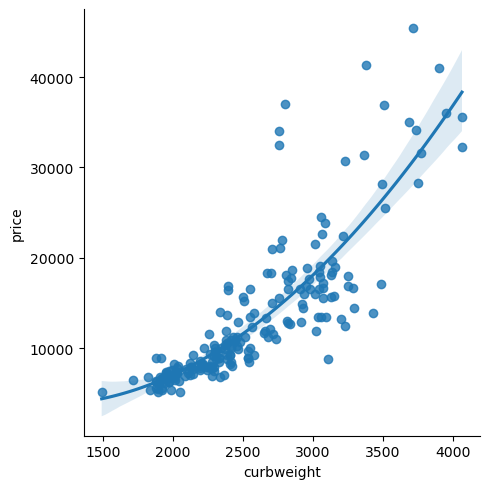

In [15]:
# Grafica la relación entre 'curbweight' (peso del auto) y 'price' (precio)
# usando un scatter plot con una curva de regresión polinomial.
# order=2 indica que ajusta un polinomio de grado 2 (curva cuadrática),
# en lugar de una línea recta.
sns.lmplot(x='curbweight', y='price', data=data, order=2)


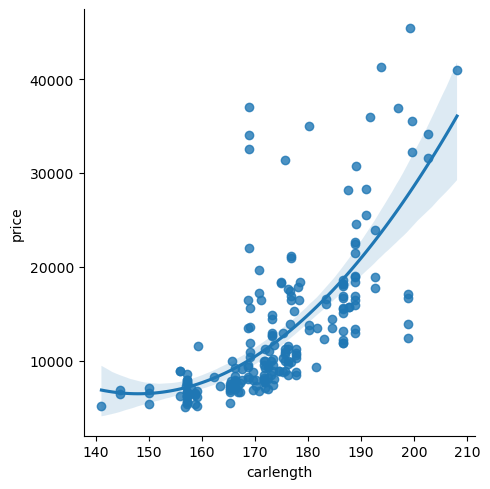

In [16]:
sns.lmplot(x = 'carlength', y = 'price', data = data, order=2)

La relación es más curva.

## Ejercicio 1 
En este ejercicio, visualice la relación entre lo 'horsepower' " y la variable objetivo, el'price'.

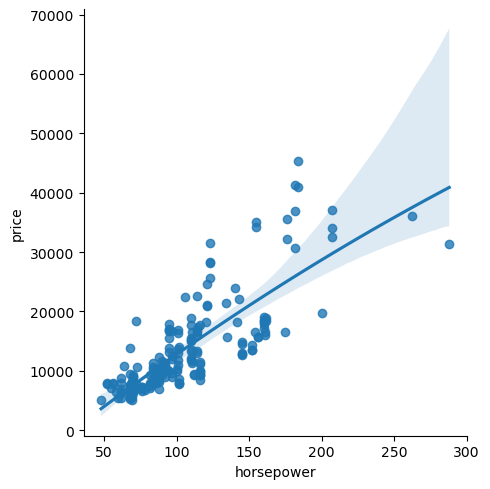

In [19]:
sns.lmplot(x = 'horsepower', y = 'price', data = data, order=2)

## Preparación de datos 
Primero dividiremos nuestros datos en ```X``` características ```y``` yobjetivos.

In [21]:
X = data.drop('price', axis=1)
y = data.price

## División de pruebas de tren 
Ahora que hemos dividido nuestros datos en conjuntos de entrenamiento y prueba, los datos de entrenamiento se utilizan para que su modelo reconozca patrones utilizando algunos criterios, y el conjunto de datos de prueba se utiliza para evaluar su modelo, como se muestra en la siguiente imagen:

<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/images/trin-test.png">
</center>
<center>source scikit-learn.org</center>


Ahora, dividimos nuestros datos, usando la función <code>train_test_split</code>  , en los conjuntos de entrenamiento y prueba, asignando el 30% de los datos para las pruebas.

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=42)
print("Number of test samples:", X_test.shape[0])
print("Number of training samples:", X_train.shape[0])


Number of test samples: 62
Number of training samples: 143


## Funciones múltiples 

Vamos a crear un objeto <code>LinearRegression</code>  llamado `lm`.

In [27]:
lm = LinearRegression()

Ahora, ajustemos el modelo con múltiples características en nuestros datos X_train e y_train.

In [29]:
lm.fit(X_train, y_train)

LinearRegression()

Aplicamos la función `predict()`  en el conjunto de datos de prueba.

In [31]:
predicted = lm.predict(X_test)

In [32]:
predicted

array([27679.53125, 21386.65625, 10772.0625 , 12139.46875, 26089.84375,
        5435.71875,  8130.40625,  7555.65625, 10135.875  ,  9485.8125 ,
       17343.625  ,  7276.71875, 16493.90625, 10815.71875, 39689.     ,
        5562.75   ,  2497.5625 , 15677.5625 , 10791.90625, 11484.1875 ,
       10839.96875, 15755.     , 10499.40625,  3634.03125,  7026.96875,
       28668.375  , 18354.9375 , 15181.90625,  4451.8125 , 16394.8125 ,
       26754.90625,  5840.34375,  4854.5    , 16620.125  ,  8376.4375 ,
       30354.46875, 12330.375  , 13007.75   ,  6307.3125 , 16110.625  ,
        8165.21875, 15138.0625 , 14739.0625 ,  5250.40625,  6259.125  ,
        9130.21875,  5840.34375,  7284.03125, 16674.90625, 15535.28125,
        5057.6875 , 21874.40625,  7105.78125, 11433.5625 ,  4388.78125,
       16528.0625 , 18374.34375, 13007.75   , 29719.53125,  5446.53125,
        9788.875  , 16993.78125])

In [33]:
y_test

15     30760.000
9      17859.167
100     9549.000
132    11850.000
68     28248.000
         ...    
56     11845.000
128    37028.000
76      5389.000
144     9233.000
104    17199.000
Name: price, Length: 62, dtype: float64

Calculemos en ambos conjuntos de datos el `r2_score()` , de entrenamiento y de prueba.

In [35]:
print("R^2 on training  data ",lm.score(X_train, y_train))
print("R^2 on testing data ",lm.score(X_test,y_test))

R^2 on training  data  0.92626533006977
R^2 on testing data  0.8478797750436009


We can plot distributions of the predicted values versus the actual values. 


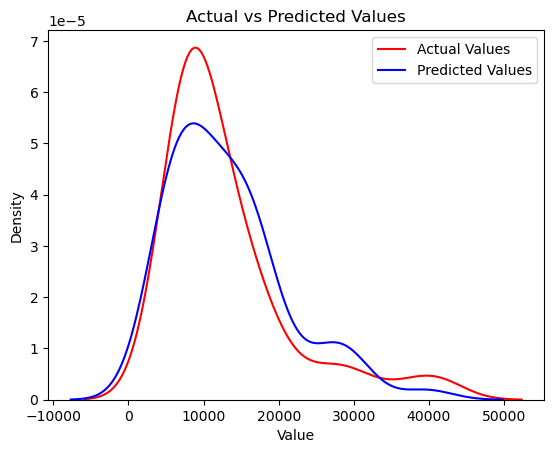

In [37]:
plot_dis(y_test,predicted)

A continuación, veremos los coeficientes estimados para el problema de regresión lineal.

In [39]:
# Crea un diccionario que asocia cada nombre de columna (feature)
# con su coeficiente correspondiente del modelo lineal.
# zip(X.columns, lm.coef_) empareja cada columna con su coeficiente.
# El diccionario resultante tiene la forma:
# {"feature_1": coef_1, "feature_2": coef_2, ...}
{col: coef for col, coef in zip(X.columns, lm.coef_)}


{'diesel': 173288834788427.38,
 'gas': 173288834786874.88,
 'std': 322.6006326086436,
 'turbo': -319.25547880004984,
 'convertible': 1769.8961729655746,
 'hardtop': 3131.5917131662613,
 'hatchback': -1757.0531327286305,
 'sedan': -677.1005521467303,
 'wagon': -2481.4805421324613,
 '4wd': -637.3830438007827,
 'fwd': -269.8330707675496,
 'rwd': 898.1523273241057,
 'dohc': 2469.033677301364,
 'dohcv': -13312.303678206019,
 'l': 2159.751853350836,
 'ohc': 4649.190286213528,
 'ohcf': 6103.9902978625905,
 'ohcv': -2845.3144933761005,
 'rotor': 782.9366711403865,
 'eight': 9226.499420944367,
 'five': -2734.5269332477023,
 'four': -5342.343904683697,
 'six': -2147.3992286475036,
 'three': -0.000244140625,
 'twelve': 214.85571426282021,
 'two': 782.9327648903865,
 'wheelbase': 101.8726068206642,
 'curbweight': 4.848079732557239,
 'enginesize': 23.568875421562197,
 'boreratio': -1780.5478609050253,
 'horsepower': 68.47600443650647,
 'carlength': -65.89428139323942,
 'carwidth': 577.933324031322,

Como vemos, los dos primeros coeficientes son demasiado grandes para graficarlos, por lo que los descartaremos y graficaremos el resto de los coeficientes.

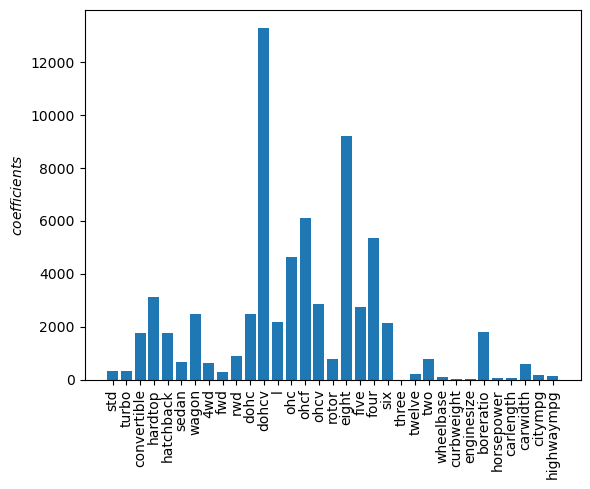

In [41]:
# Crea un gráfico de barras para visualizar los coeficientes del modelo lineal.
# Se excluyen las dos primeras columnas y sus coeficientes (X.columns[2:], lm.coef_[2:])
# y se toma el valor absoluto de los coeficientes para comparar magnitudes.
plt.bar(X.columns[2:], abs(lm.coef_[2:]))

# Rota las etiquetas del eje X 90° para que se puedan leer verticalmente.
plt.xticks(rotation=90)

# Etiqueta del eje Y indicando que se muestran los coeficientes del modelo.
plt.ylabel("$coefficients$")

# Muestra el gráfico.
plt.show()


## Interpretación de la Importancia de los Coeficientes

Generalmente podemos interpretar que los coeficientes más grandes tienen mayor importancia en la predicción, ya que representan la magnitud del impacto que cada variable tiene sobre el valor estimado por el modelo.  

Sin embargo, **esto no siempre es así**, y es importante tener en cuenta varios factores:

- **Escala de las variables:**  
  Un coeficiente grande puede deberse únicamente a que la variable tiene una escala distinta (por ejemplo, kilómetros vs. metros). Por eso suele ser necesario **escalar** o **estandarizar** las variables antes del entrenamiento.

- **Colinealidad entre variables:**  
  Si varias características están altamente correlacionadas, los coeficientes pueden volverse poco estables o distribuirse entre variables similares, dificultando su interpretación.

- **Tipo de modelo utilizado:**  
  En modelos lineales los coeficientes tienen una interpretación directa, pero en modelos más complejos (árboles, SVM, redes neuronales) los coeficientes dejan de ser una medida de importancia.

- **Regularización:**  
  Técnicas como **Ridge** o **Lasso** modifican los coeficientes para reducir el sobreajuste, lo que también afectu magnitud.

---

Por lo tanto, aunque los coeficientes pueden ofrecernos una primera idea de la importancia de cada característica, **no siempre son una medida confiable por sí solos**.  
A continuación analizaremos cada variable de manera individual para obtener una comprensión más completa de su contribución al modelo.


## Características individuales

Podemos entrenar el modelo y trazar nuestro análisis **para cada una de las características** de los conjuntos de datos de entrenamiento y prueba, utilizando la función `get_R2_features`.  

Esta función nos permite:

- Evaluar **qué tan bien cada característica por sí sola puede predecir la variable objetivo**.
- Comparar el desempeño del modelo en **train y test** para detectar posibles problemas de sobreajuste.
- Visualizar los resultados mediante **gráficas de barras**, donde se muestran los valores de $R^2$ de entrenamiento y prueba para cada variable.
- Identificar cuáles características tienen un mayor poder predictivo y cuáles podrían aportar poca información al modelo.

En resumen, nos ayuda a **entender la importancia y el impacto individual de cada variable**, antes de entrenar un modelo más complejo que utilice todas las características simultáneamente.


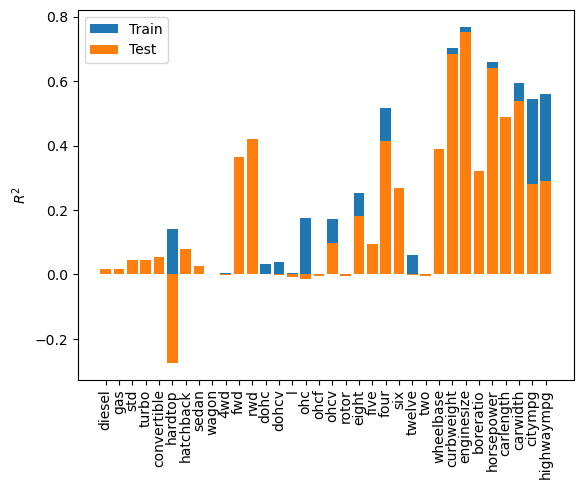

Training R^2 mean value 0.21817773426877918 Testing R^2 mean value 0.1824149303513927 
Training R^2 max value 0.7686929078033782 Testing R^2 max value 0.7534902447506853 


In [44]:
get_R2_features(lm)

## Interpretación de las características individuales y coeficientes

Del gráfico anterior, podemos observar que algunas características individuales **tienen un desempeño similar** al de usar todas las variables juntas, lo que nos indica que estas features por sí solas ya contienen información relevante para la predicción.

Cabe destacar que en este análisis **eliminamos la característica `three`**, por lo que los resultados se basan en las demás variables del conjunto de datos.

Además, se nota un patrón interesante: **algunas características con coeficientes pequeños parecen asociarse a predicciones más estables**, mientras que **los coeficientes más grandes a veces indican sobreajuste**.  

En otras palabras, un coeficiente grande no siempre significa que la característica es más importante; puede ser una señal de que el modelo está **sobreajustando** esa variable, es decir, ajustándose demasiado a los datos de entrenamiento sin generalizar bien al conjunto de
 
Es decir, vemos que los coeficientes más pequeños parecen corresponder a un coeficiente $R^{2}$ más grande.
, por lo tanto, los coeficientes mayores corresponden a sobreajuste.prueba.
.

## Relación entre R² individual y coeficiente

Cuando analizamos una característica individual en un modelo lineal, es importante diferenciar entre **R²** y **coeficiente**, ya que no siempre coinciden en su interpretación:

- **R² de una sola característica:**  
  Mide qué tan bien esa variable por sí sola explica la variabilidad de la variable objetivo. Es un indicador de su poder predictivo individual.

- **Coeficiente:**  
  Indica cuánto cambia la predicción por unidad de cambio en esa variable dentro del modelo lineal. Su magnitud depende de la escala de la variable y de la presencia de otras variables correlacionadas.

- **No siempre coinciden:**
  - Una variable puede tener un R² alto pero un coeficiente pequeño (por ejemplo, si su escala es grande o si los datos están normalizados).  
  - Una variable puede tener un coeficiente grande pero un R² bajo, lo que a v**eces indica sobreajuste o c**olinealidad.

- **Regla práctica:**  
  - **R² individual:** indica la capacidad predictiva de la variable.  
  - **Coeficiente:** indica la influencia de la variable en el modelo.  
  Ambos deben interpretarse juntos para obtener conclusiones confiables y evitar errores de interpretación.


## Ejercicio 2 
En este ejercicio, calcule la $R^2$ utilizando el objeto Pipeline para regresión lineal y aplicarle ```StandardScaler()``` a todas las características, luego use la función ```plot_dis``` para comparar los valores predichos con los valores reales.

R^2 on training data: 0.9262722224294516
R^2 on testing data: 0.8419174509630339


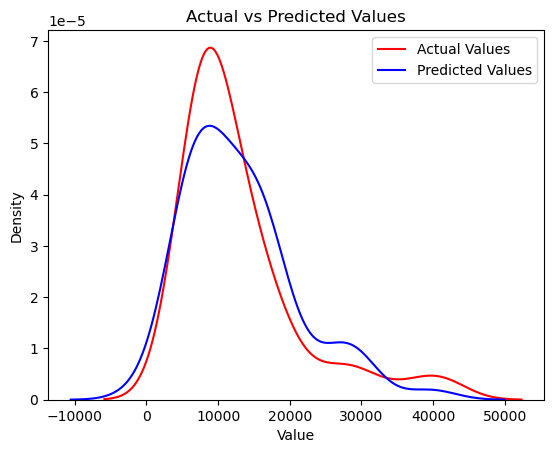

In [48]:
# Creamos un pipeline que primero estandariza las variables y luego aplica regresión lineal
pipe = Pipeline([
    ('ss', StandardScaler()),  # Estandariza los datos (media=0, desviación estándar=1)
    ('lr', LinearRegression()) # Modelo de regresión lineal
])

# Entrenamos el pipeline con los datos de entrenamiento
pipe.fit(X_train, y_train)

# Imprimimos el R² del modelo sobre los datos de entrenamiento
print("R^2 on training data:", pipe.score(X_train, y_train))

# Imprimimos el R² del modelo sobre los datos de prueba
print("R^2 on testing data:", pipe.score(X_test, y_test))

# Generamos las predicciones sobre los datos de prueba
predicted = pipe.predict(X_test)

# Comparamos visualmente las distribuciones de los valores reales vs predichos
plot_dis(y_test, predicted)


## Ejercicio 3 
En este ejercicio, calcule l $R^2$  a
utilizando el objeto Pipeline c ```StandardScaler()``` ()para cada característica individual utilizando la funció```get_R2_features```.s.

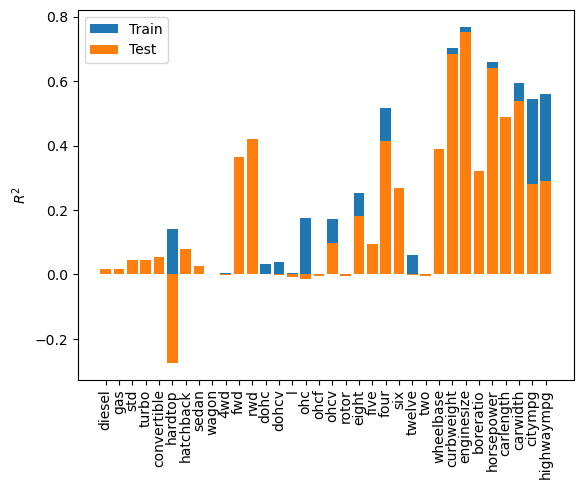

Training R^2 mean value 0.21817773426877915 Testing R^2 mean value 0.18241493035139264 
Training R^2 max value 0.7686929078033782 Testing R^2 max value 0.7534902447506853 


In [50]:
pipe = Pipeline([('ss',StandardScaler() ),('lr', LinearRegression())])
get_R2_features(pipe)

## Características polinómicas 
### Funciones múltiples 


La transformación polinómica es una forma sencilla de aumentar la complejidad del modelo, pero debemos tener cuidado con el sobrellenado. A continuación, realizaremos una transformación polinómica de segundo grado (grado = 2).

In [52]:
# Crea un transformador que genera características polinomiales de grado 2 a partir de las originales,
# sin agregar un término constante (bias). Útil para que modelos lineales capturen relaciones no lineales.
poly_features = PolynomialFeatures(degree=2, include_bias=False)


Ahora, transformamos los conjuntos de datos de entrenamiento y prueba.

In [54]:
# ================================
# Transformación polinomial de grado 2
# ================================

# En el conjunto de entrenamiento:
# fit_transform hace dos cosas:
# 1. fit -> aprende los parámetros de la transformación (qué combinaciones polinomiales crear)
#           Ejemplo conceptual: si X_train tiene dos columnas [x1, x2], fit determina que
#           las nuevas columnas serán [x1, x2, x1^2, x1*x2, x2^2]
# 2. transform -> aplica esa transformación a X_train y genera X_train_poly
# Esto es importante porque el modelo debe aprender las relaciones polinomiales solo de los datos de entrenamiento.
X_train_poly = poly_features.fit_transform(X_train)

# En el conjunto de prueba:
# transform se usa sin fit, porque ya aprendimos la transformación de X_train.
# Esto asegura que no se filtre información del test durante el entrenamiento.
# Ejemplo conceptual: si X_test tiene columnas [x1, x2], transform generará [x1, x2, x1^2, x1*x2, x2^2]
# exactamente igual que X_train_poly, manteniendo consistencia entre entrenamiento y prueba.
X_test_poly = poly_features.transform(X_test)


`X_train_poly` y `X_test_poly` ahora contiene las características originales de X más el cuadrado de estas características y la combinación de términos cruzados. Revisemos la forma de los conjuntos de tren y prueba recién creados.

In [56]:
print(X_train_poly.shape)


(143, 665)


In [57]:
print(X_test_poly.shape)

(62, 665)


En total, tenemos 665 características. Ahora, ajustamos el modelo con las características recién creadas.

In [59]:
lm = LinearRegression()
lm.fit(X_train_poly, y_train)

LinearRegression()

And we make predictions.


In [61]:
predicted = lm.predict(X_train_poly)

Nuevamente, podemos verificar `r2_score()` tanto el conjunto de datos de entrenamiento como el de prueba.

In [63]:
print("R^2 on training data:", lm.score(X_train_poly, y_train))
print("R^2 on testing data:", lm.score(X_test_poly,y_test))

R^2 on training data: 0.9985318497975855
R^2 on testing data: -36729.95849951847


Vemos que el modelo tiene un  $R^{2}$ negativo
**En el conjunto de datos de prueba, esto es un signo de sobreajuste.**

### Características individuales 
Las **canalizaciones** de datos simplifican el procesamiento de datos. Usamos el módulo <code>Pipeline</code> para crear una canalización. También la usamos <code>PolynomialFeatures</code>  como un paso en nuestra canalización.

In [65]:
# Definimos los pasos de la canalización (pipeline)
Input = [
    # Paso 1: Transformador de características polinómicas
    # Convierte las variables originales en combinaciones polinómicas hasta grado 2
    # include_bias=False evita agregar la columna de unos (intercepto)
    ('polynomial', PolynomialFeatures(include_bias=False, degree=2)),

    # Paso 2: Modelo de regresión lineal
    # Se ajustará a los datos transformados por el paso anterior
    ('model', LinearRegression())
]

We can repeat the steps above, using the <code>Pipleine</code> object.


In [67]:
pipe=Pipeline(Input)
pipe.fit(X_train, y_train)

Pipeline(steps=[('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

Podemos ver que los resultados son idénticos.

In [69]:
print("R^2 on training  data:", pipe.score(X_train, y_train))
print("R^2 on testing data:", pipe.score(X_test,y_test))

R^2 on training  data: 0.9985318497975855
R^2 on testing data: -36729.95849951847


Podemos entrenar nuestro modelo en cada una de las características utilizando la transformada de característica polinómica de segundo grado. Luego, podemos graficar nuestra $R^2$. .

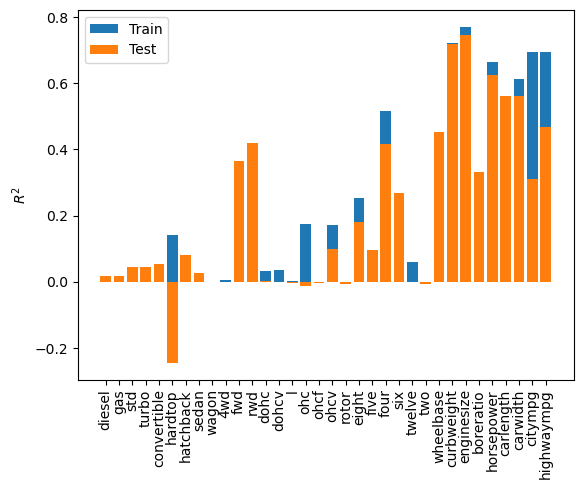

Training R^2 mean value 0.23080994197684732 Testing R^2 mean value 0.19482428470984473 
Training R^2 max value 0.7706959974452947 Testing R^2 max value 0.7463370080614307 


In [71]:
get_R2_features(pipe)

Característica con el máximo $R^{2}$ es mayor que cuando se utilizan todas las funciones.

## GridSearch y Pipeline - Teoría

En machine learning, optimizar el rendimiento de un modelo no solo depende de elegir el algoritmo correcto, sino también de ajustar sus **hiperparámetros**, que son configuraciones externas al modelo y que afectan directamente su comportamiento. Para abordar esto de manera sistemática, utilizamos dos herramientas clave: **Pipeline** y **GridSearchCV**.#

## Pipeline

Un **Pipeline** (o canalización) es una secuencia de pasos que define un flujo de trabajo completo para el procesamiento de datos y el entrenamiento del modelo. Sus ventajas incluyen:

1. **Organización:** Permite encadenar transformaciones y el modelo final en un solo objeto.
2. **Reproducibilidad:** Garantiza que los mismos pasos de preprocesamiento se apliquen tanto a los datos de entrenamiento como a los datos de prueba.
3. **Evita fugas de información:** Al incluir transformaciones dentro del pipeline, se asegura que los datos de prueba no influyan en el ajuste de las transformaciones.

Un pipeline típico puede incluir pasos como:
- Normalización o estandarización de datos.
- Codificación de variables categóricas.
- Selección de características.
- Entrenamiento# del modelo.

## GridSearchCV

**GridSearchCV** es una técnica de búsqueda exhaustiva que permite encontrar la combinación óptima de hiperparámetros para un modelo. Los conceptos clave son:

- **Parámetros a explorar:** Se define un "grid" o cuadrícula que contiene distintas combinaciones de valores de los hiperparámetros.
- **Validación cruzada:** Para cada combinación de hiperparámetros, se evalúa el rendimiento del modelo mediante k-fold cross-validation, normalmente con k=5 por defecto.
- **Selección del mejor modelo:** GridSearchCV devuelve la combinación de hiperparámetros que maximiza una métrica de evaluación definida (por ejemplo, precisión, F1-score o error# cuadrático medio).

### Ventajas de GridSearchCV

- Automatiza el proceso de búsqueda de hiperparámetros.
- Reduce el riesgo de sobreajuste al validar con diferentes particiones de los datos.
- Permite comparar de manera justa múltiples conf#iguraciones de un modelo.

### Flujo de trabajo general

1. Definir un **Pipeline** con los pasos de preprocesamiento y el modelo.
2. Definir una **cuadrícula de hiperparámetros** a evaluar.
3. Ejecutar **GridSearchCV** para probar todas las combinaciones.
4. Seleccionar el **modelo con mejor rendimiento** según la validación cruzada.
5. Evaluar el modelo final en datos de prueba no vistos.

En la siguiente lección, profundizaremos en la **validación cruzada de k pasos**, explicando su importancia y cómo elegir el valor de k para equilibrar **sesgo y varianza**.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML240EN-SkillsNetwork/images/k-fold.png">
</center>
<center>source scikit-learn.org</center>


Creamos `PolynomialFeatures()`  pipeline.

In [76]:
# Definimos los pasos del pipeline como una lista de tuplas
# Cada tupla tiene la forma (nombre_del_paso, transformador_o_modelo)
Input = [
    ('scaler', StandardScaler()),  # Paso 1: Normaliza los datos (media=0, desviación estándar=1)
    ('polynomial', PolynomialFeatures(include_bias=False, degree=2)),  
    # Paso 2: Crea nuevas características polinómicas hasta grado 2 (sin columna de unos)
    ('model', LinearRegression())   # Paso 3: Ajusta un modelo de regresión lineal a los datos transformados
]

# Creamos el pipeline con los pasos definidos
pipe = Pipeline(Input)


In [77]:
pipe

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

# Búsqueda de Hiperparámetros con GridSearchCV en Pipelines

## 1. ¿Qué es GridSearchCV?
`GridSearchCV` es una herramienta de `scikit-learn` que permite probar automáticamente muchas combinaciones de **hiperparámetros** y seleccionar la mejor según un criterio de evaluación (por ejemplo, exactitud, precisión, F1, etc.).

> **Hiperparámetros**: Son parámetros que no se aprenden directamente del entrenamiento del modelo, como `C` en un SVM o `n_estimators` en un RandomFore

---

## 2. Diccionario de Hiperparámetros
Para indicarle a `GridSearchCV` qué combinaciones probar, usamos un **diccionario de parámetros**, donde:

- La **clave** identifica el hiperparámetro.
- El **valor** es una lista con los posibles valores que queremos probar.

Para buscar la mejor combinación de hiperparámetros, creamos un objeto **GridSearchCV** con un diccionario de valores de parámetros. Los parámetros de las canalizaciones se pueden configurar usando el nombre de la clave, separado por '__', y luego el nombre del parámetro de la clave.

In [80]:
# Diccionario de hiperparámetros para GridSearchCV
param_grid = {
    # 'polynomial' es el nombre de un paso en un pipeline (por ejemplo, PolynomialFeatures)
    # 'degree' es el hiperparámetro que indica el grado del polinomio
    # Se prueban los valores 1, 2 y 3 para encontrar cuál produce el mejor rendimiento
    "polynomial__degree": [1, 2, 3]
}


**polynomial__degree :** es el grado del polinomio.

In [82]:
search = GridSearchCV(pipe, param_grid, n_jobs=1)

In [83]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial', PolynomialFeatures(include_bias=False)),
                ('model', LinearRegression())])

In [84]:
search.fit(X_test, y_test)

GridSearchCV(estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('polynomial',
                                        PolynomialFeatures(include_bias=False)),
                                       ('model', LinearRegression())]),
             n_jobs=1, param_grid={'polynomial__degree': [1, 2, 3]})

El objeto encuentra los mejores valores de parámetro en los datos de validación. Podemos obtener el estimador con los mejores parámetros y asignarlo a la variable ```best```, como se indica a continuación:

In [86]:
best=search.best_estimator_
best

Pipeline(steps=[('scaler', StandardScaler()),
                ('polynomial',
                 PolynomialFeatures(degree=3, include_bias=False)),
                ('model', LinearRegression())])

Vemos que el grado es uno y normalizar es <code>Ture </code>.

Ahora, probamos nuestro modelo en los datos de prueba para ver la mejor puntuación.

In [88]:
best.score(X_test,y_test)

0.9999040661085455

Finalmente, podemos trazar una distribución de los valores predichos versus los valores reales.

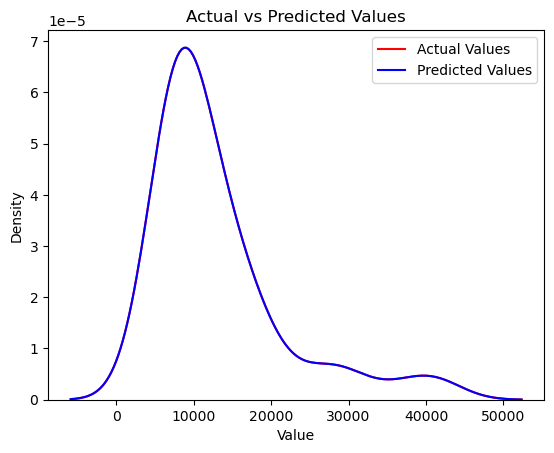

In [90]:
predicted=best.predict(X_test)
plot_dis(y_test,predicted)

¡Como vemos el resultado es casi perfecto!

## Ejercicio 4 
En este ejercicio, calcule la $R^2$  utilizando el objeto ```Pipeline``` con ```GridSearch``` cada característica individual.

diesel
gas
std
turbo
convertible
hardtop
hatchback
sedan
wagon
4wd
fwd
rwd
dohc
dohcv
l
ohc
ohcf
ohcv
rotor
eight
five
four
six
three
twelve
two
wheelbase
curbweight
enginesize
boreratio
horsepower
carlength
carwidth
citympg
highwaympg


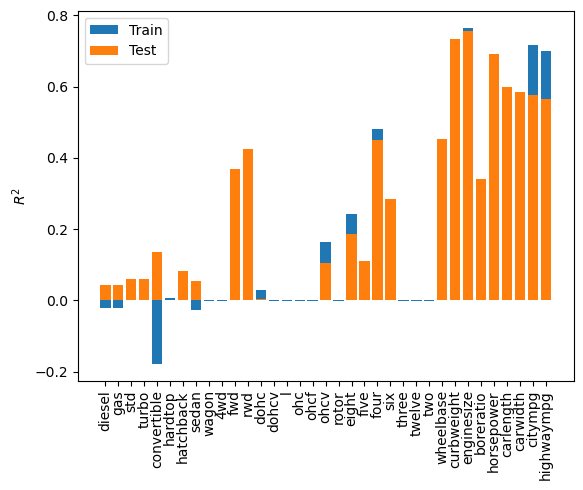

Training R^2 mean value 0.18708323249920522 Testing R^2 mean value 0.2204167156337184 
Training R^2 max value 0.765323637379124 Testing R^2 max value 0.7565151400968062 


In [92]:
features=list(X)
   
    
R_2_train=[]
R_2_test=[]

for feature in features:
    param_grid = {
    "polynomial__degree": [ 1, 2,3,4,5],
    "model__positive":[True, False]}
    Input=[ ('polynomial', PolynomialFeatures(include_bias=False,degree=2)), ('model',LinearRegression())]
    pipe=Pipeline(Input)
    print(feature)
    search = GridSearchCV(pipe, param_grid, n_jobs=2)
    search.fit(X_test[[feature]], y_test)
    best=search.best_estimator_
        
    R_2_test.append(best.score(X_test[[feature]],y_test))
    R_2_train.append(best.score(X_train[[feature]],y_train))
    
        
plt.bar(features,R_2_train,label="Train")
plt.bar(features,R_2_test,label="Test")
plt.xticks(rotation=90)
plt.ylabel("$R^2$")
plt.legend()
plt.show()
print("Training R^2 mean value {} Testing R^2 mean value {} ".format(str(np.mean(R_2_train)),str(np.mean(R_2_test))) )
print("Training R^2 max value {} Testing R^2 max value {} ".format(str(np.max(R_2_train)),str(np.max(R_2_test))) )


<!--## Change Log
-->


<!--| Date (YYYY-MM-DD) | Version | Changed By            | Change Description                   |
| ----------------- | ------- | --------------------- | ------------------------------------ |
|   2022-04-15      | 0.1     | Svitlana K.           | Created the first draft |
|   2022-04-18      | 0.1     | Joseph S.             | Updated all content |
|   2022-04-26      | 0.1     | Svitlana K.           | Corrected minor grammar errors |-->

